## Imports and paths

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (precision_score,  recall_score,  roc_auc_score,  accuracy_score,  f1_score,  confusion_matrix,  roc_curve)

## 1. Modeling preparation

In [3]:
DATA_DIR = Path("../Cleaned Data/Splits")  # Training and test set folder
RANDOM_STATE = 1948883                     # Using My ID as a random seed, make the results reproducible.
N_SPLITS = 5                               # 5-fold cross-validation


# 4 modeling tasks
TASKS ={
    "before_mask": "Before mandate - Face mask",                    # 1. Face mask behavior prediction before mask mandate
    "after_mask": "After mandate - Face mask",                      # 2. Face mask behavior prediction after mask mandate
    "before_protective": "Before mandate - Protective behaviour",   # 3. Protective behavior prediction before mask mandate
    "after_protective": "After mandate - Protective behaviour",     # 4. Protective behavior prediction after mask mandate
}


# Evaluation indicators
METRICS = ["precision", "recall", "roc_auc", "accuracy", "f1"]

## 2. Define Model

In [4]:
# Read the corresponding training and test sets based on the task name.
def load_task(task):
    X_train = pd.read_csv(DATA_DIR / f"X_train_{task}.csv")
    X_test = pd.read_csv(DATA_DIR / f"X_test_{task}.csv")
    y_train = pd.read_csv(DATA_DIR / f"y_train_{task}.csv").iloc[:, 0].astype(int)
    y_test = pd.read_csv(DATA_DIR / f"y_test_{task}.csv").iloc[:, 0].astype(int)
    return X_train, X_test, y_train, y_test


# Balanced class distribution is performed only on the training set.
def upsample(X, y, seed):
    ros = RandomOverSampler(random_state=seed)
    X_up, y_up = ros.fit_resample(X, y)
    return X_up, pd.Series(y_up)


# Logistic Regression model
def build_model():
    return LogisticRegression(max_iter=5000, solver="liblinear", random_state=RANDOM_STATE)


# Calculate evaluation indicators
def get_metrics(y_true, y_pred, y_prob):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }


# Save results
results = {}         # Detailed results for each task
cv_summary = []      # Average cross-validation result for each task
test_summary = []    # Final results on the test set

## 3. Model training and prediction

In [5]:
# Perform Logistic Regression modeling on the 4 tasks

for task, label in TASKS.items():
    X_train, X_test, y_train, y_test = load_task(task)    # Read the data


    # 5-fold cross-validation.
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE) 
    cv_rows = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        X_tr_up, y_tr_up = upsample(X_tr, y_tr, RANDOM_STATE)

        model = build_model()
        model.fit(X_tr_up, y_tr_up)

        y_val_pred = model.predict(X_val)
        y_val_prob = model.predict_proba(X_val)[:, 1]

        row = get_metrics(y_val, y_val_pred, y_val_prob)
        row["fold"] = fold
        cv_rows.append(row)


    # Organize the results of all folds into a DataFrame
    cv_df = pd.DataFrame(cv_rows)


    # Calculate the average performance
    cv_mean = cv_df[METRICS].mean().to_dict()
    cv_mean["task"] = task
    cv_mean["label"] = label


    # Save results
    cv_summary.append(cv_mean)


    # Train
    X_train_up, y_train_up = upsample(X_train, y_train, RANDOM_STATE)
    final_model = build_model()
    final_model.fit(X_train_up, y_train_up)


    # Predict
    y_test_pred = final_model.predict(X_test)
    y_test_prob = final_model.predict_proba(X_test)[:, 1]


    # Calculate evaluation indicators
    test_row = get_metrics(y_test, y_test_pred, y_test_prob)
    test_row["task"] = task
    test_row["label"] = label
    test_summary.append(test_row)


    # Save all important results
    coef_df = pd.DataFrame({
        "feature": X_train.columns,
        "coefficient": final_model.coef_[0],
        "abs_coefficient": np.abs(final_model.coef_[0])
    }).sort_values("abs_coefficient", ascending=False)

    results[task] = {
        "label": label,
        "cv_df": cv_df,
        "test_metrics": test_row,
        "y_test": y_test,
        "y_test_pred": y_test_pred,
        "y_test_prob": y_test_prob,
        "coef_df": coef_df,
        "cm": confusion_matrix(y_test, y_test_pred)
    }

## 4. Results

### 4.1 Cross-validation average 

In [6]:
cv_summary_df = pd.DataFrame(cv_summary)[["task", "label"] + METRICS]

print("CV mean results")
display(cv_summary_df.round(4))

CV mean results


,task,label,precision,recall,roc_auc,accuracy,f1
0,before_mask,Before mandate - Face mask,0.5104,0.7743,0.8212,0.7292,0.6152
1,after_mask,After mandate - Face mask,0.8789,0.7795,0.8357,0.7690,0.8262
2,before_protective,Before mandate - Protective behaviour,0.6581,0.6991,0.7334,0.6726,0.6779
3,after_protective,After mandate - Protective behaviour,0.8423,0.7265,0.7777,0.7146,0.7801


### 4.2 Final test set results

In [7]:
test_summary_df = pd.DataFrame(test_summary)[["task", "label"] + METRICS]

print("Test results")
display(test_summary_df.round(4))

Test results


,task,label,precision,recall,roc_auc,accuracy,f1
0,before_mask,Before mandate - Face mask,0.5091,0.7794,0.8284,0.7281,0.6159
1,after_mask,After mandate - Face mask,0.8855,0.7833,0.8444,0.7759,0.8313
2,before_protective,Before mandate - Protective behaviour,0.6434,0.6911,0.7217,0.6590,0.6664
3,after_protective,After mandate - Protective behaviour,0.8381,0.7253,0.7690,0.7109,0.7776


### 4.3 Bar charts of various indicators

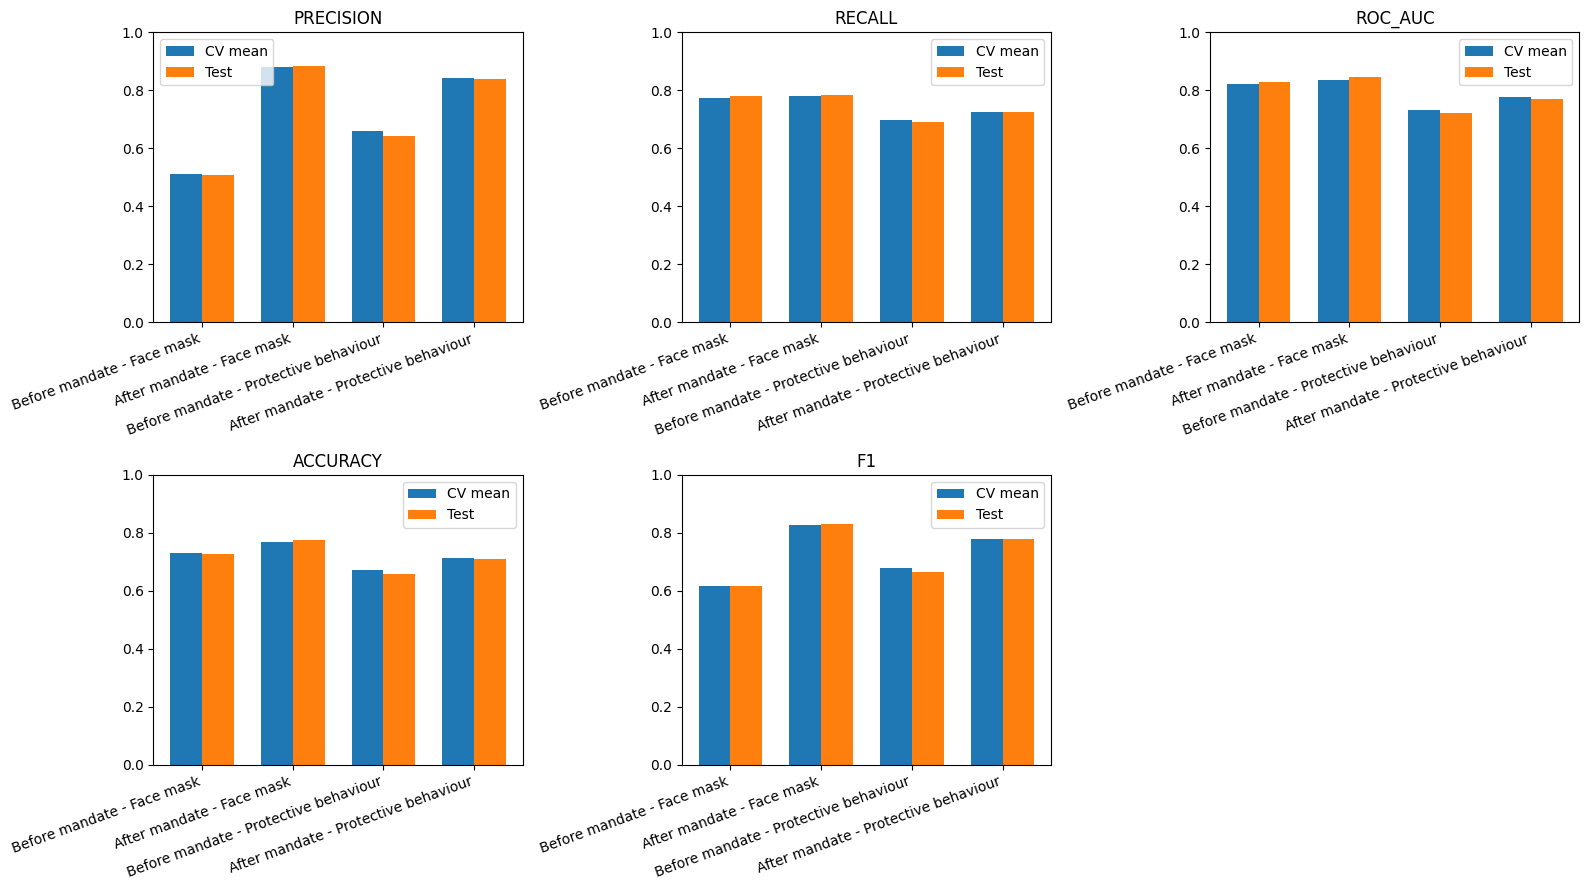

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, metric in enumerate(METRICS):
    ax = axes[i]
    cv_vals = cv_summary_df.set_index("task").loc[list(TASKS.keys()), metric]
    test_vals = test_summary_df.set_index("task").loc[list(TASKS.keys()), metric]

    x = np.arange(len(TASKS))
    width = 0.35

    ax.bar(x - width/2, cv_vals.values, width=width, label="CV mean")
    ax.bar(x + width/2, test_vals.values, width=width, label="Test")
    ax.set_xticks(x)
    ax.set_xticklabels(list(TASKS.values()), rotation=20, ha="right")
    ax.set_ylim(0, 1)
    ax.set_title(metric.upper())
    ax.legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()


### 4.4 ROC curve

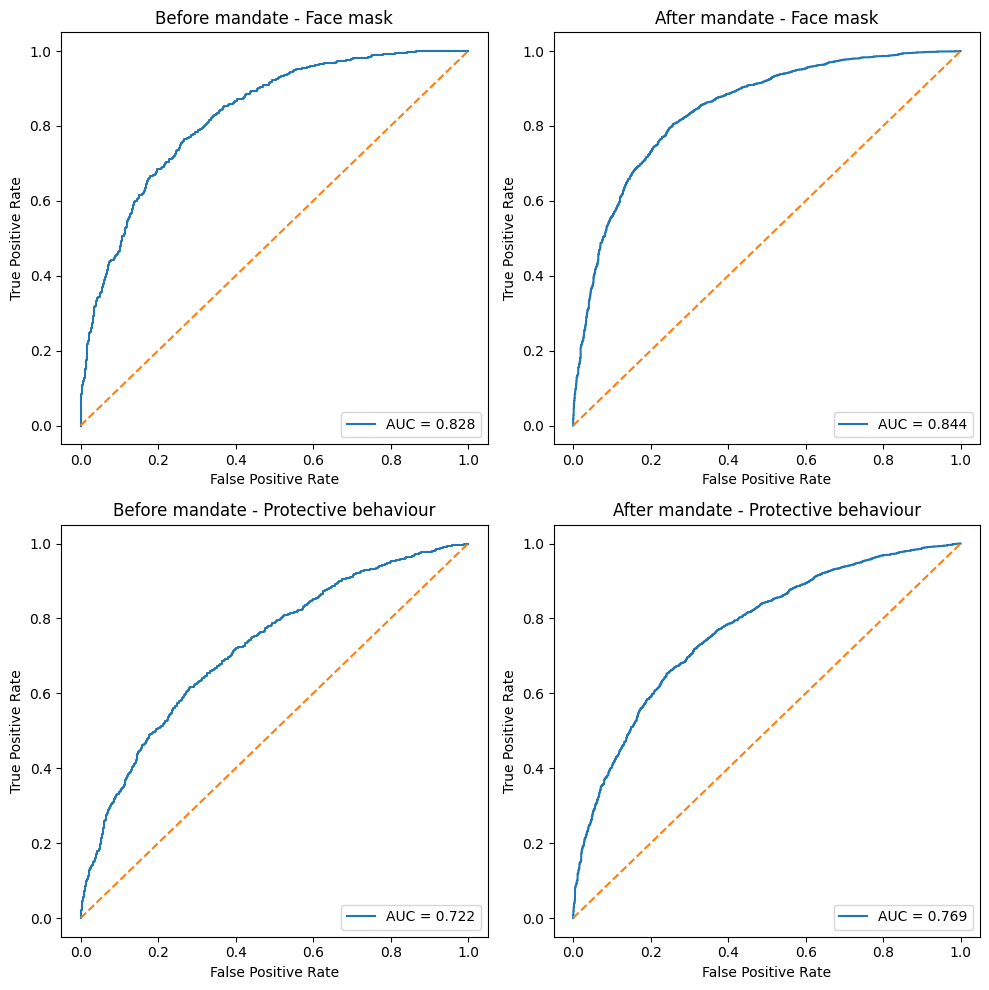

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, task in zip(axes, TASKS.keys()):
    y_test = results[task]["y_test"]
    y_prob = results[task]["y_test_prob"]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(TASKS[task])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


### 4.5 confusion matrix heatmap。

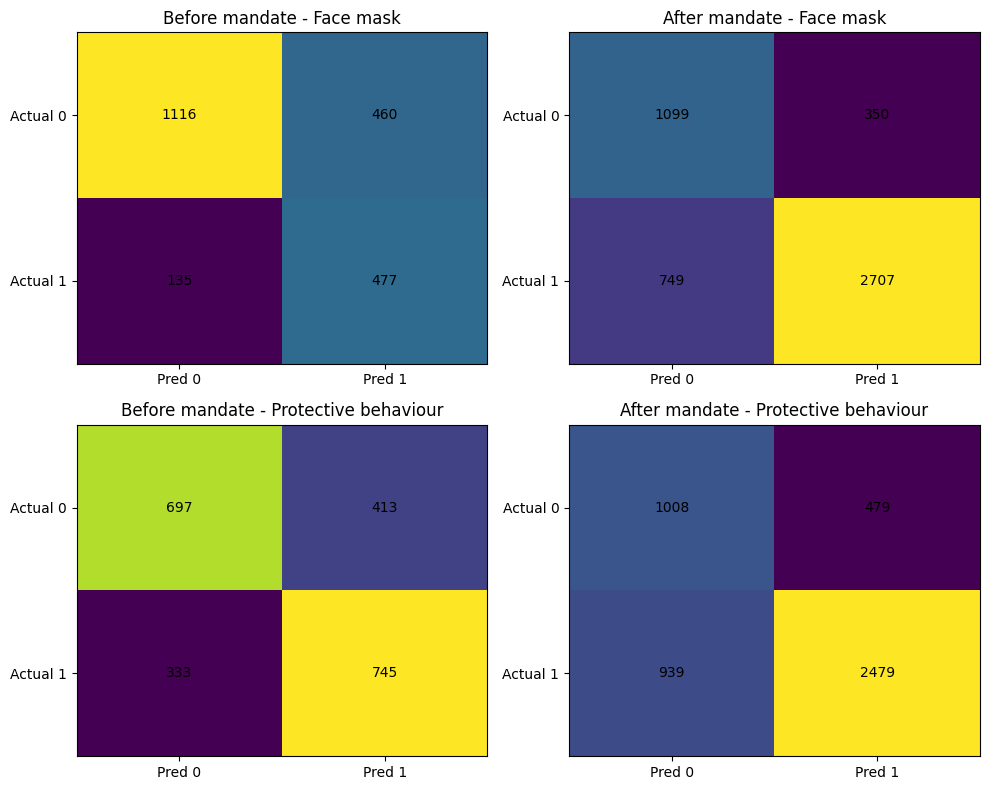

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, task in zip(axes, TASKS.keys()):
    cm = results[task]["cm"]
    ax.imshow(cm, aspect="auto")
    ax.set_title(TASKS[task])
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["Actual 0", "Actual 1"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center")

plt.tight_layout()
plt.show()


### 4.6 All Model Indicators 

In [11]:
metric_order = ["roc_auc", "f1", "accuracy", "precision", "recall"]
metric_names = {
    "roc_auc": "AUC",
    "f1": "F1",
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
}

task_order = list(TASKS.keys())

cv_tbl = (
    cv_summary_df
    .set_index("task")
    .loc[task_order, ["label"] + metric_order]
    .copy()
)

test_tbl = (
    test_summary_df
    .set_index("task")
    .loc[task_order, metric_order]
    .copy()
)

summary_table = pd.DataFrame({
    "Task": cv_tbl["label"].values
})

for metric in metric_order:
    summary_table[f"CV {metric_names[metric]}"] = cv_tbl[metric].round(3).values
    summary_table[f"Test {metric_names[metric]}"] = test_tbl[metric].round(3).values

display(summary_table)


,Task,CV AUC,Test AUC,CV F1,Test F1,CV Accuracy,Test Accuracy,CV Precision,Test Precision,CV Recall,Test Recall
0,Before mandate - Face mask,0.821,0.828,0.615,0.616,0.729,0.728,0.510,0.509,0.774,0.779
1,After mandate - Face mask,0.836,0.844,0.826,0.831,0.769,0.776,0.879,0.886,0.780,0.783
2,Before mandate - Protective behaviour,0.733,0.722,0.678,0.666,0.673,0.659,0.658,0.643,0.699,0.691
3,After mandate - Protective behaviour,0.778,0.769,0.780,0.778,0.715,0.711,0.842,0.838,0.727,0.725
